In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.7 MB/s eta 0:00:0000:0100:01


In [3]:
import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
source_dir = r'/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset'
dataset_path = source_dir
target_dir = r'/kaggle/working/yolo_cls_dataset'
excel_path = r'/kaggle/input/datasets/yashbhakte/fabric-dd-reason-dataset/Fabric Defect ReasonMachineSuggestion Dataset.xlsx'

# Remove old copy if exists
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)

os.makedirs(os.path.join(target_dir, 'train'), exist_ok=True)
os.makedirs(os.path.join(target_dir, 'val'), exist_ok=True)

class_names = sorted([
    f for f in os.listdir(source_dir)
    if os.path.isdir(os.path.join(source_dir, f))
])

for cls in class_names:
    cls_source = os.path.join(source_dir, cls)
    images = os.listdir(cls_source)

    train_imgs, val_imgs = train_test_split(
        images,
        test_size=0.2,
        random_state=42
    )

    os.makedirs(os.path.join(target_dir, 'train', cls), exist_ok=True)
    os.makedirs(os.path.join(target_dir, 'val', cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_source, img),
            os.path.join(target_dir, 'train', cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(cls_source, img),
            os.path.join(target_dir, 'val', cls, img)
        )

print("YOLO classification dataset prepared successfully!")
print("Saved at:", target_dir)
print("Total classes:", len(class_names))
print("Classes:", class_names)


YOLO classification dataset prepared successfully!
Saved at: /kaggle/working/yolo_cls_dataset
Total classes: 9
Classes: ['Broken stitch', 'Needle mark', 'Pinched fabric', 'Vertical', 'defect free', 'hole', 'horizontal', 'lines', 'stain']


In [6]:
from ultralytics import YOLO

model = YOLO("/kaggle/input/models/yashbhakte/yolo-model/pytorch/default/1/best.pt")


In [7]:
best_model = YOLO("/kaggle/input/models/yashbhakte/yolo-model/pytorch/default/1/best.pt")

sample_class = class_names[0]
sample_folder = os.path.join(dataset_path, sample_class)
sample_image = os.path.join(sample_folder, os.listdir(sample_folder)[0])

results = best_model.predict(sample_image, verbose=False)

predicted_index = int(results[0].probs.top1)
predicted_class = results[0].names[predicted_index]
confidence = float(results[0].probs.top1conf)

print("Image path:", sample_image)
print("Predicted class:", predicted_class)
print("Confidence:", confidence)


Image path: /kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Broken stitch/A_02_014.jpg
Predicted class: Broken stitch
Confidence: 0.999923586845398


In [8]:
metadata_df = pd.read_excel(excel_path)

print(metadata_df.head())


  Defect Category                 1st Priority (Most Likely)  \
0           stain       75%: Oil leakage from bearings/cams.   
1            hole     80%: Broken needle hook or sharp part.   
2      horizontal  70%: Yarn feeder timing or tension error.   
3        Vertical         75%: Misaligned or damaged needle.   
4           lines   70%: Constant tension pulses/vibrations.   

                   2nd Priority (Check Next )  \
0    20%: Dirt or sweat from manual handling.   
1      15%: Weak yarn snapping under tension.   
2            25%: Faulty Bobbin/Pirn tension.   
3  20%: Sinker damage or warp thread missing.   
4     25%: Yarn slubs or irregular thickness.   

                           3rd Priority (Rare)            Machine Responsible  \
0       5%: Rust marks from old machine parts.    Any Machine (Spinning/Loom)   
1       5%: Rough handling/snagging by worker.  Knitting Machine / Power Loom   
2     5%: Variation in yarn thickness (Count).        Circular / Shuttle Loom

In [9]:
def normalize_defect_name(name):
    return str(name).strip().lower().replace('-', ' ')

mapping_data = {}

for _, row in metadata_df.iterrows():
    defect_name = normalize_defect_name(row['Defect Category'])

    mapping_data[defect_name] = {
        "reason_1": str(row.get('1st Priority (Most Likely)', '')),
        "reason_2": str(row.get('2nd Priority (Check Next )', '')),
        "reason_3": str(row.get('3rd Priority (Rare)', '')),
        "suggestion": str(row.get('Suggestion to reduce future defect', '')),
        "machine": str(row.get('Machine Responsible', ''))
    }

print("Mapping created successfully!")
print(json.dumps(mapping_data, indent=2))


Mapping created successfully!
{
  "stain": {
    "reason_1": "75%: Oil leakage from bearings/cams.",
    "reason_2": "20%: Dirt or sweat from manual handling.",
    "reason_3": "5%: Rust marks from old machine parts.",
    "suggestion": "Clean oil seals; enforce worker hand-hygiene protocols.",
    "machine": "Any Machine (Spinning/Loom)"
  },
  "hole": {
    "reason_1": "80%: Broken needle hook or sharp part.",
    "reason_2": "15%: Weak yarn snapping under tension.",
    "reason_3": "5%: Rough handling/snagging by worker.",
    "suggestion": "Inspect needle bed; replace dull hooks; test yarn strength.",
    "machine": "Knitting Machine / Power Loom"
  },
  "horizontal": {
    "reason_1": "70%: Yarn feeder timing or tension error.",
    "reason_2": "25%: Faulty Bobbin/Pirn tension.",
    "reason_3": "5%: Variation in yarn thickness (Count).",
    "suggestion": "Recalibrate feeder timing; check bobbin winding pressure.",
    "machine": "Circular / Shuttle Loom"
  },
  "vertical": {
   

In [10]:
val_dir = "/kaggle/working/yolo_cls_dataset/val"

y_true = []
y_pred = []

val_class_names = sorted([
    f for f in os.listdir(val_dir)
    if os.path.isdir(os.path.join(val_dir, f))
])

for class_name in val_class_names:
    class_folder = os.path.join(val_dir, class_name)

    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)

        results = best_model.predict(img_path, verbose=False)
        pred_index = int(results[0].probs.top1)
        pred_class = results[0].names[pred_index]

        y_true.append(class_name)
        y_pred.append(pred_class)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("===== METRICS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred, zero_division=0))


===== METRICS =====
Accuracy : 0.9564
Precision: 0.9606
Recall   : 0.9564
F1-score : 0.9570

===== CLASSIFICATION REPORT =====
                precision    recall  f1-score   support

 Broken stitch       1.00      1.00      1.00        23
   Needle mark       1.00      1.00      1.00        22
Pinched fabric       1.00      1.00      1.00        22
      Vertical       0.80      0.95      0.87        21
   defect free       1.00      0.96      0.98       334
          hole       0.90      0.91      0.90        57
    horizontal       1.00      0.82      0.90        28
         lines       0.90      0.88      0.89        32
         stain       0.86      1.00      0.92        80

      accuracy                           0.96       619
     macro avg       0.94      0.95      0.94       619
  weighted avg       0.96      0.96      0.96       619



In [11]:
def full_prediction_yolo(img_path):
    # Show image
    img = mpimg.imread(img_path)
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Image")
    plt.show()

    # YOLO prediction
    results = best_model.predict(img_path, verbose=False)

    predicted_index = int(results[0].probs.top1)
    predicted_class = results[0].names[predicted_index]
    confidence = float(results[0].probs.top1conf)

    normalized_defect = normalize_defect_name(predicted_class)

    print("===== FINAL RESULT =====")
    print(f"Defect: {predicted_class}")
    print(f"Confidence: {confidence:.4f}")

    if normalized_defect != "defect free":
        info = mapping_data.get(normalized_defect, {})

        print("\nReasons:")
        print(f"1.: {info.get('reason_1', 'Not available')}")
        print(f"2.: {info.get('reason_2', 'Not available')}")
        print(f"3.: {info.get('reason_3', 'Not available')}")

        print(f"\nSuggestion: {info.get('suggestion', 'Not available')}")
        print(f"Machine: {info.get('machine', 'Not available')}")
    else:
        print("\nFabric is defect free.")


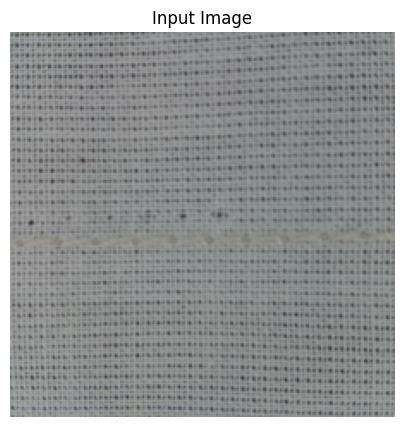

===== FINAL RESULT =====
Defect: Needle mark
Confidence: 1.0000

Reasons:
1.: 80%: Bent or damaged needle/latch.
2.: 15%: Worn-out needle grooves.
3.: 5%: Incorrect needle size for fabric weight.

Suggestion: Replace needles immediately; check latch movement/grooves.
Machine: Circular Knitting Machine


In [12]:
full_prediction_yolo(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Needle mark/A_08_027.jpg"
)


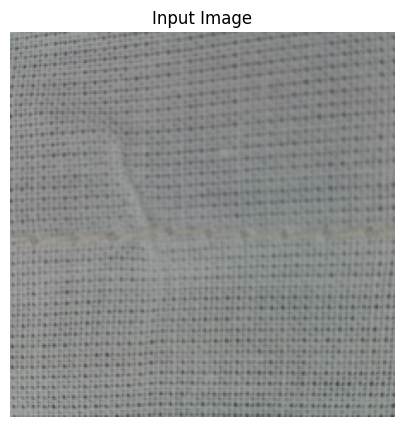

===== FINAL RESULT =====
Defect: Pinched fabric
Confidence: 0.9999

Reasons:
1.: 75%: Uneven roller pressure.
2.: 20%: Presser foot too tight.
3.: 5%: Fabric fold during feeding process.

Suggestion: Recalibrate pneumatic roller pressure; adjust presser foot.
Machine: Inspection / Finishing Machine


In [13]:
full_prediction_yolo(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Pinched fabric/A_03_014.jpg"
)


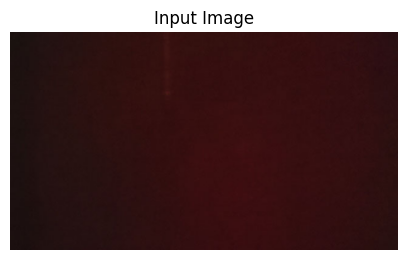

===== FINAL RESULT =====
Defect: Vertical
Confidence: 0.6956

Reasons:
1.: 75%: Misaligned or damaged needle.
2.: 20%: Sinker damage or warp thread missing.
3.: 5%: Static buildup in the yarn path.

Suggestion: Align needle frame; check sinkers for metal burrs or lint.
Machine: Warp Knitting / Weaving Loom


In [14]:

full_prediction_yolo(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/Vertical/13.jpg"
)



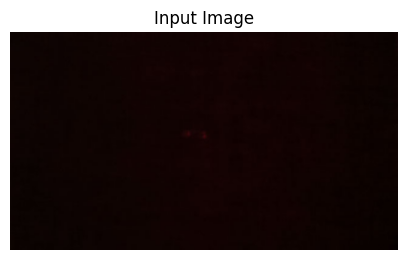

===== FINAL RESULT =====
Defect: hole
Confidence: 0.9712

Reasons:
1.: 80%: Broken needle hook or sharp part.
2.: 15%: Weak yarn snapping under tension.
3.: 5%: Rough handling/snagging by worker.

Suggestion: Inspect needle bed; replace dull hooks; test yarn strength.
Machine: Knitting Machine / Power Loom


In [15]:

full_prediction_yolo(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/hole/17.jpg"
)



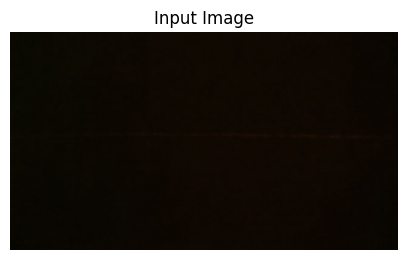

===== FINAL RESULT =====
Defect: horizontal
Confidence: 0.9995

Reasons:
1.: 70%: Yarn feeder timing or tension error.
2.: 25%: Faulty Bobbin/Pirn tension.
3.: 5%: Variation in yarn thickness (Count).

Suggestion: Recalibrate feeder timing; check bobbin winding pressure.
Machine: Circular / Shuttle Loom


In [16]:

full_prediction_yolo(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/horizontal/15.jpg"
)



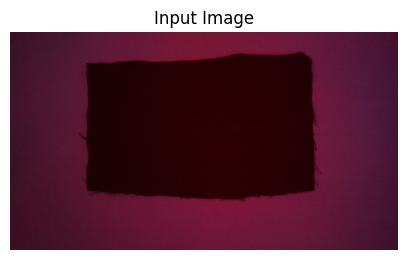

===== FINAL RESULT =====
Defect: lines
Confidence: 0.9959

Reasons:
1.: 70%: Constant tension pulses/vibrations.
2.: 25%: Yarn slubs or irregular thickness.
3.: 5%: Rolling vibration in the machine frame.

Suggestion: Check machine mounting; stabilize tension rollers; check yarn.
Machine: Any High-Speed Machine


In [17]:

full_prediction_yolo(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/lines/line_2018-10-10 10_05_44.703532.jpg"
)



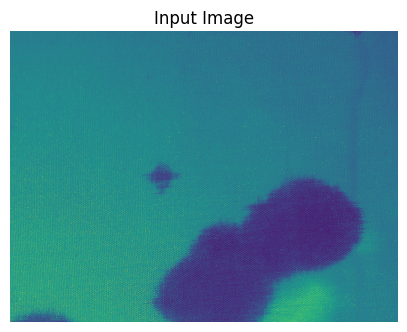

===== FINAL RESULT =====
Defect: stain
Confidence: 0.9998

Reasons:
1.: 75%: Oil leakage from bearings/cams.
2.: 20%: Dirt or sweat from manual handling.
3.: 5%: Rust marks from old machine parts.

Suggestion: Clean oil seals; enforce worker hand-hygiene protocols.
Machine: Any Machine (Spinning/Loom)


In [18]:

full_prediction_yolo(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/stain/118.jpg"
)



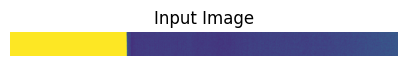

===== FINAL RESULT =====
Defect: defect free
Confidence: 0.9999

Fabric is defect free.


In [19]:

full_prediction_yolo(
    "/kaggle/input/datasets/ziya07/multi-class-fabric-defect-detection-dataset/Dataset/defect free/0004_000_00.png"
)



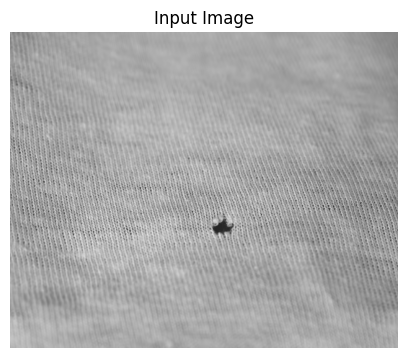

===== FINAL RESULT =====
Defect: stain
Confidence: 0.9101

Reasons:
1.: 75%: Oil leakage from bearings/cams.
2.: 20%: Dirt or sweat from manual handling.
3.: 5%: Rust marks from old machine parts.

Suggestion: Clean oil seals; enforce worker hand-hygiene protocols.
Machine: Any Machine (Spinning/Loom)


In [24]:

full_prediction_yolo(
    "/kaggle/input/datasets/yashbhakte/google-hole/hole-fabric_469558-31953.avif"
)

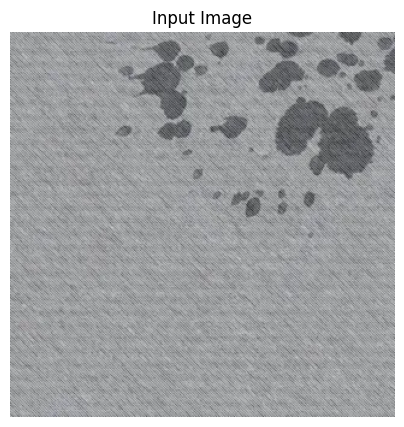

===== FINAL RESULT =====
Defect: stain
Confidence: 0.9985

Reasons:
1.: 75%: Oil leakage from bearings/cams.
2.: 20%: Dirt or sweat from manual handling.
3.: 5%: Rust marks from old machine parts.

Suggestion: Clean oil seals; enforce worker hand-hygiene protocols.
Machine: Any Machine (Spinning/Loom)


In [25]:

full_prediction_yolo(
    "/kaggle/input/datasets/yashbhakte/google-stain/fabric-stain-defect.webp"
)

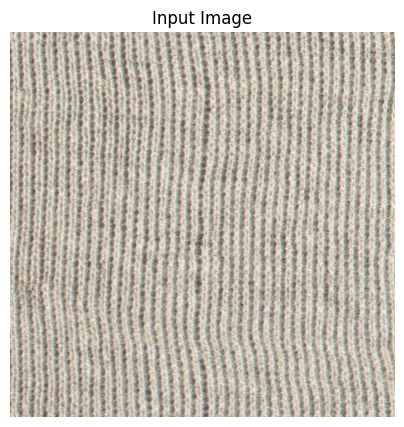

===== FINAL RESULT =====
Defect: defect free
Confidence: 1.0000

Fabric is defect free.


In [26]:

full_prediction_yolo(
    "/kaggle/input/datasets/yashbhakte/goggle-needle/0179_Needle-Line-1.jpg"
)